
SUMMARY TABLE

                         Method  Nodes  Cov_mean  Red_mean  Etot_mean  Nact_mean  Connected_mean  AvgRsActive_mean  NodeScore_mean  CompareScore_mean  BestOverall  Rank
                Grid Deployment     16   0.80000   0.12800   0.003146      16.00            0.00         18.000000             NaN           0.000000        False     3
Proposed Smart Placement Scheme     16   0.57752   0.52272   0.004785      12.05            1.00         16.409374       -0.128159           0.069490         True     1
              Random Deployment     16   0.76152   0.62904   0.003111      16.00            0.20         18.000000             NaN           0.022809        False     2
                Grid Deployment     25   1.00000   0.64000   0.003335      25.00            0.00         17.760000             NaN           0.000000        False     3
Proposed Smart Placement Scheme     25   0.84624   1.26304   0.009865      24.65            1.00         17.802652       -0.135400         

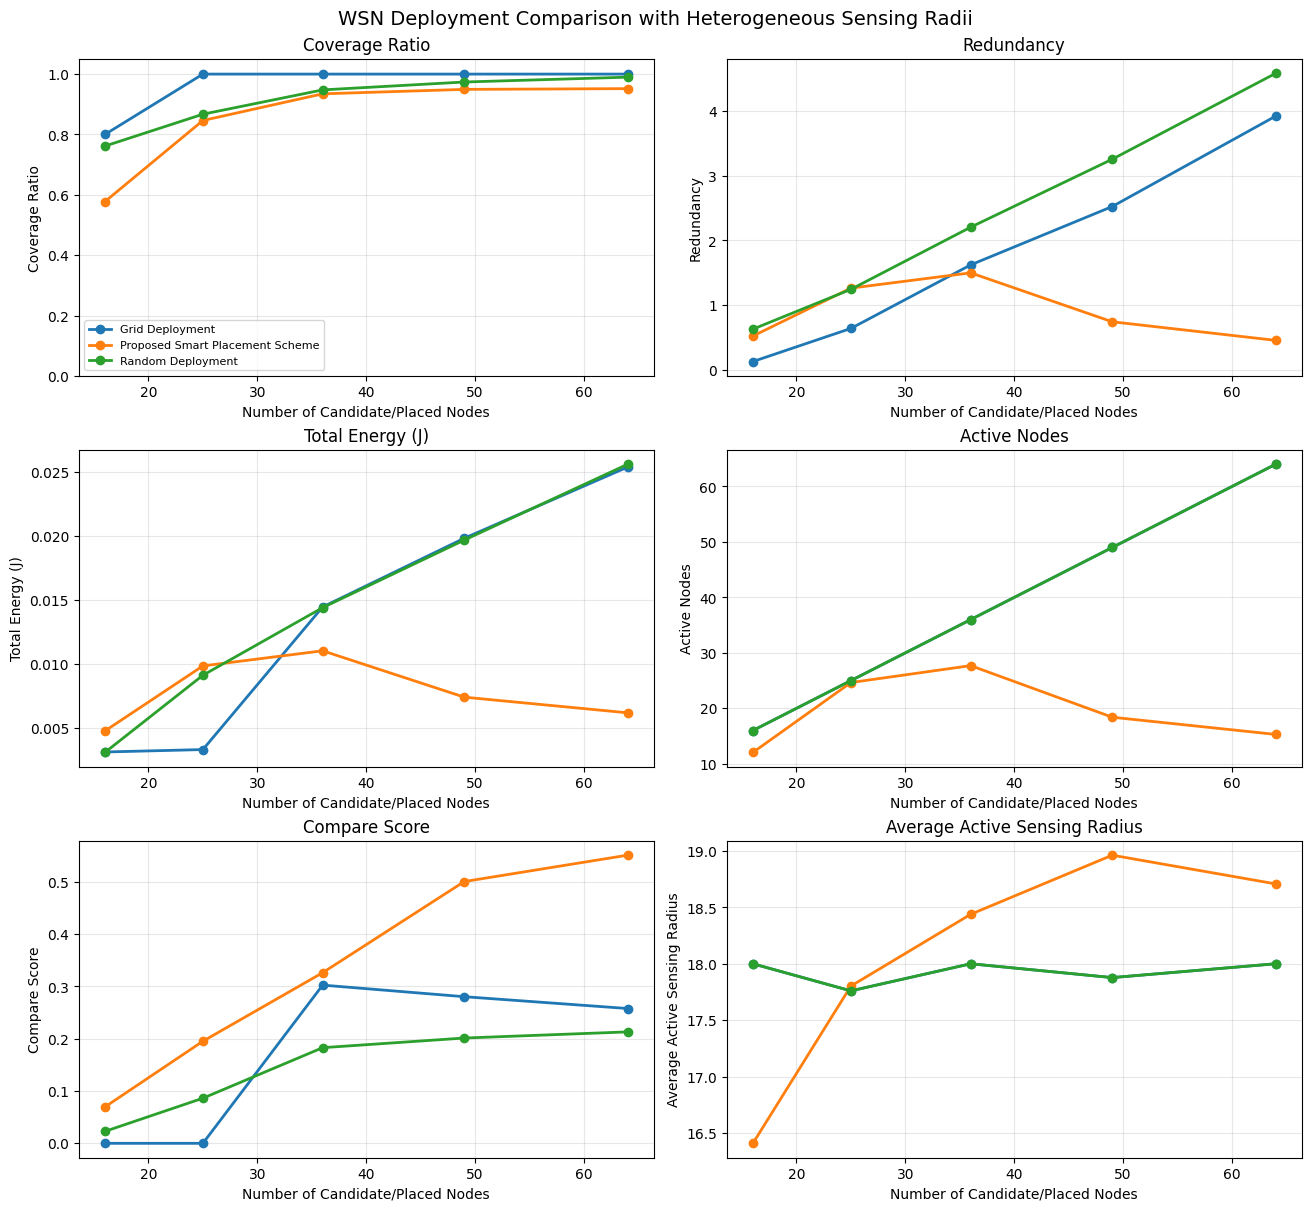


Saved CSV and LaTeX table to: /content/wsn_outputs_v4


In [1]:
#!/usr/bin/env python3
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple
import heapq
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


@dataclass
class Config:
    field_w: float = 100.0
    field_h: float = 100.0
    sink: Tuple[float, float] = (110.0, 50.0)

    # Heterogeneous sensing radii from the report
    sensing_radii: Tuple[float, ...] = (12.0, 16.0, 20.0, 24.0)

    # Communication radius is set per node as Rc_i = 2 * Rs_i
    target_grid_nx: int = 25
    target_grid_ny: int = 25
    packet_bits: int = 4000
    e_elec: float = 50e-9
    eps_fs: float = 10e-12
    eps_mp: float = 0.0013e-12
    e_sense_base: float = 5e-6
    coverage_target: float = 0.95

    # Node score weights
    alpha: float = 0.60
    beta: float = 0.25
    gamma: float = 0.15

    # Large penalty applied when topology is disconnected
    penalty_disconnected: float = 1e6

    node_counts: Tuple[int, ...] = (16, 25, 36, 49, 64)
    trials: int = 20
    seed: int = 7

    @property
    def d0(self) -> float:
        return math.sqrt(self.eps_fs / self.eps_mp)

    @property
    def mean_rs(self) -> float:
        return float(np.mean(self.sensing_radii))


def make_target_points(cfg: Config) -> np.ndarray:
    xs = np.linspace(0, cfg.field_w, cfg.target_grid_nx)
    ys = np.linspace(0, cfg.field_h, cfg.target_grid_ny)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()])


def random_positions(n: int, cfg: Config, rng: np.random.Generator) -> np.ndarray:
    return np.column_stack([
        rng.uniform(0, cfg.field_w, size=n),
        rng.uniform(0, cfg.field_h, size=n),
    ])


def grid_positions(n: int, cfg: Config) -> np.ndarray:
    side = math.ceil(math.sqrt(n))
    xs = np.linspace(0.0, cfg.field_w, side)
    ys = np.linspace(0.0, cfg.field_h, side)
    pts = np.array([(x, y) for y in ys for x in xs], dtype=float)
    return pts[:n]


def assign_node_radii(n: int, cfg: Config, rng: np.random.Generator, mode: str = "random") -> np.ndarray:
    base = np.array(cfg.sensing_radii, dtype=float)
    reps = int(np.ceil(n / len(base)))
    rs = np.tile(base, reps)[:n].copy()
    if mode == "random":
        rng.shuffle(rs)
    return rs


def pairwise_dist(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.sqrt(((a[:, None, :] - b[None, :, :]) ** 2).sum(axis=2))


def coverage_counts(points: np.ndarray, targets: np.ndarray, rs: np.ndarray) -> np.ndarray:
    if len(points) == 0:
        return np.zeros(len(targets), dtype=int)
    d = pairwise_dist(points, targets)
    return (d <= rs[:, None]).astype(np.int32).sum(axis=0)


def coverage_redundancy(points: np.ndarray, targets: np.ndarray, rs: np.ndarray):
    counts = coverage_counts(points, targets, rs)
    cov = np.minimum(1, counts).mean()
    red = np.maximum(0, counts - 1).mean()
    return float(cov), float(red), counts


def build_graph(points: np.ndarray, sink: Tuple[float, float], rc: np.ndarray):
    n = len(points)
    sink_pt = np.array(sink, dtype=float)
    graph = [[] for _ in range(n + 1)]
    if n == 0:
        return graph

    d = pairwise_dist(points, points)
    for i in range(n):
        for j in range(i + 1, n):
            if d[i, j] <= min(rc[i], rc[j]):
                w = float(d[i, j])
                graph[i].append((j, w))
                graph[j].append((i, w))

    sink_id = n
    ds = np.linalg.norm(points - sink_pt[None, :], axis=1)
    for i in range(n):
        if ds[i] <= rc[i]:
            w = float(ds[i])
            graph[i].append((sink_id, w))
            graph[sink_id].append((i, w))
    return graph


def connected_to_sink(points: np.ndarray, sink: Tuple[float, float], rc: np.ndarray) -> bool:
    n = len(points)
    if n == 0:
        return True
    graph = build_graph(points, sink, rc)
    seen, stack = {n}, [n]
    while stack:
        u = stack.pop()
        for v, _ in graph[u]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return all(i in seen for i in range(n))


def shortest_path_tree(points: np.ndarray, sink: Tuple[float, float], rc: np.ndarray):
    n = len(points)
    graph = build_graph(points, sink, rc)
    sink_id = n
    dist = [float("inf")] * (n + 1)
    parent = [-1] * (n + 1)
    dist[sink_id] = 0.0
    pq = [(0.0, sink_id)]
    while pq:
        du, u = heapq.heappop(pq)
        if du != dist[u]:
            continue
        for v, w in graph[u]:
            nd = du + w
            if nd < dist[v]:
                dist[v] = nd
                parent[v] = u
                heapq.heappush(pq, (nd, v))
    return dist, parent


def tx_energy(k_bits: int, d: float, cfg: Config) -> float:
    if d < cfg.d0:
        return k_bits * cfg.e_elec + k_bits * cfg.eps_fs * (d ** 2)
    return k_bits * cfg.e_elec + k_bits * cfg.eps_mp * (d ** 4)


def rx_energy(k_bits: int, cfg: Config) -> float:
    return k_bits * cfg.e_elec


def node_sense_energy(rs_i: float, cfg: Config) -> float:
    return cfg.e_sense_base * (rs_i / cfg.mean_rs)


def total_energy(points: np.ndarray, rs: np.ndarray, cfg: Config):
    if len(points) == 0:
        return 0.0, True

    rc = 2.0 * rs
    connected = connected_to_sink(points, cfg.sink, rc)

    # Compute communication energy only for the component that can reach the sink.
    # No artificial penalty is applied for disconnected deployments.
    graph = build_graph(points, cfg.sink, rc)
    n = len(points)
    sink_id = n

    seen = {sink_id}
    stack = [sink_id]
    while stack:
        u = stack.pop()
        for v, _ in graph[u]:
            if v not in seen:
                seen.add(v)
                stack.append(v)

    connected_nodes = [i for i in range(n) if i in seen]
    if not connected_nodes:
        return 0.0, False

    sub_points = points[connected_nodes]
    sub_rs = rs[connected_nodes]
    sub_rc = 2.0 * sub_rs

    _, parent = shortest_path_tree(sub_points, cfg.sink, sub_rc)
    m = len(sub_points)
    children = [0] * m
    hop_dist = [0.0] * m

    for i in range(m):
        p = parent[i]
        if p == -1:
            continue
        if p < m:
            children[p] += 1
            d = np.linalg.norm(sub_points[i] - sub_points[p])
        else:
            d = np.linalg.norm(sub_points[i] - np.array(cfg.sink))
        hop_dist[i] = float(d)

    total = 0.0
    for i in range(m):
        total += (
            node_sense_energy(float(sub_rs[i]), cfg)
            + tx_energy(cfg.packet_bits, hop_dist[i], cfg)
            + children[i] * rx_energy(cfg.packet_bits, cfg)
        )

    return total, connected


def evaluate(points: np.ndarray, rs: np.ndarray, cfg: Config, targets: np.ndarray) -> Dict[str, float]:
    cov, red, _ = coverage_redundancy(points, targets, rs)
    etot, connected = total_energy(points, rs, cfg)
    return {
        "Cov": cov,
        "Red": red,
        "Etot": etot,
        "Nact": float(len(points)),
        "Connected": float(connected),
        "AvgRsActive": float(np.mean(rs)) if len(rs) else 0.0,
    }


def connectivity_feasible(candidate: np.ndarray, rs_i: float, current_points: np.ndarray, current_rs: np.ndarray, cfg: Config) -> bool:
    rc_i = 2.0 * rs_i
    if len(current_points) == 0:
        return np.linalg.norm(candidate - np.array(cfg.sink)) <= rc_i
    if np.linalg.norm(candidate - np.array(cfg.sink)) <= rc_i:
        return True
    dists = np.linalg.norm(current_points - candidate[None, :], axis=1)
    link_ok = dists <= np.minimum(rc_i, 2.0 * current_rs)
    return bool(np.any(link_ok))


def candidate_energy_cost(candidate: np.ndarray, rs_i: float, current_points: np.ndarray, current_rs: np.ndarray, cfg: Config) -> float:
    rc_i = 2.0 * rs_i
    sink_d = float(np.linalg.norm(candidate - np.array(cfg.sink)))
    best_d = sink_d if sink_d <= rc_i else float("inf")
    if len(current_points):
        dists = np.linalg.norm(current_points - candidate[None, :], axis=1)
        link_ok = dists <= np.minimum(rc_i, 2.0 * current_rs)
        if np.any(link_ok):
            best_d = min(best_d, float(np.min(dists[link_ok])))
    if not math.isfinite(best_d):
        best_d = sink_d
    return node_sense_energy(rs_i, cfg) + tx_energy(cfg.packet_bits, best_d, cfg)


def smart_select(candidate_points: np.ndarray, candidate_rs: np.ndarray, cfg: Config, targets: np.ndarray):
    remaining = set(range(len(candidate_points)))
    current_points = np.empty((0, 2), dtype=float)
    current_rs = np.empty((0,), dtype=float)
    cov, red, counts = coverage_redundancy(current_points, targets, current_rs)
    selected_scores = []
    M = len(targets)

    while cov < cfg.coverage_target and remaining:
        feasible = []
        for idx in list(remaining):
            candidate = candidate_points[idx]
            rs_i = float(candidate_rs[idx])
            if not connectivity_feasible(candidate, rs_i, current_points, current_rs, cfg):
                continue

            trial_points = np.vstack([current_points, candidate[None, :]])
            trial_rs = np.append(current_rs, rs_i)
            _, _, trial_counts = coverage_redundancy(trial_points, targets, trial_rs)

            delta_cov = int(np.sum((trial_counts > 0) & (counts == 0)))
            delta_red = int(np.maximum(0, trial_counts - 1).sum() - np.maximum(0, counts - 1).sum())
            Ei = candidate_energy_cost(candidate, rs_i, current_points, current_rs, cfg)
            feasible.append((idx, trial_points, trial_rs, trial_counts, delta_cov, delta_red, Ei))

        if not feasible:
            break

        Emax = max(x[6] for x in feasible)
        best_idx, best_score, best_state = None, -float("inf"), None
        for idx, trial_points, trial_rs, trial_counts, delta_cov, delta_red, Ei in feasible:
            score = cfg.alpha * (delta_cov / M) - cfg.beta * (delta_red / M) - cfg.gamma * (Ei / (Emax + 1e-15))
            if score > best_score:
                best_idx = idx
                best_score = score
                trial_cov = np.minimum(1, trial_counts).mean()
                trial_red = np.maximum(0, trial_counts - 1).mean()
                best_state = (trial_points, trial_rs, trial_cov, trial_red, trial_counts)

        remaining.remove(best_idx)
        current_points, current_rs, cov, red, counts = best_state
        selected_scores.append(best_score)

    changed = True
    while changed and len(current_points) > 1:
        changed = False
        for i in range(len(current_points)):
            trial_points = np.delete(current_points, i, axis=0)
            trial_rs = np.delete(current_rs, i)
            trial_cov, _, _ = coverage_redundancy(trial_points, targets, trial_rs)
            if trial_cov >= cfg.coverage_target and connected_to_sink(trial_points, cfg.sink, 2.0 * trial_rs):
                current_points = trial_points
                current_rs = trial_rs
                changed = True
                break

    avg_node_score = float(np.mean(selected_scores)) if selected_scores else np.nan
    return current_points, current_rs, avg_node_score


def add_comparison_score(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    out = df.copy()
    out["Red_norm"] = out.groupby("Nodes")["Red"].transform(
        lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
    )
    out["Etot_norm"] = out.groupby("Nodes")["Etot"].transform(
        lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
    )

    # Base score compares coverage, redundancy, and energy.
    base_score = (
        cfg.alpha * out["Cov"]
        - cfg.beta * out["Red_norm"]
        - cfg.gamma * out["Etot_norm"]
    )

    # Strongly enforce connectivity in the final method comparison.
    # If Connected = 0, the method should never be considered best.
    # If Connected is fractional (e.g., 0.20), the score is reduced proportionally.
    out["CompareScore"] = base_score * out["Connected"]

    return out


def run_experiment(cfg: Config):
    targets = make_target_points(cfg)
    rng_master = np.random.default_rng(cfg.seed)
    rows = []
    methods = [
        "Random Deployment",
        "Grid Deployment",
        "Proposed Smart Placement Scheme",
    ]

    for n in cfg.node_counts:
        for trial in range(cfg.trials):
            rng = np.random.default_rng(int(rng_master.integers(0, 2**31 - 1)))

            rand_pts = random_positions(n, cfg, rng)
            rand_rs = assign_node_radii(n, cfg, rng, mode="random")
            rows.append({
                "Method": methods[0], "Nodes": n, "Trial": trial,
                "NodeScore": np.nan,
                **evaluate(rand_pts, rand_rs, cfg, targets)
            })

            grid_pts = grid_positions(n, cfg)
            grid_rs = assign_node_radii(n, cfg, rng, mode="ordered")
            rows.append({
                "Method": methods[1], "Nodes": n, "Trial": trial,
                "NodeScore": np.nan,
                **evaluate(grid_pts, grid_rs, cfg, targets)
            })

            cand_pts = random_positions(n, cfg, rng)
            cand_rs = assign_node_radii(n, cfg, rng, mode="random")
            smart_pts, smart_rs, avg_node_score = smart_select(cand_pts, cand_rs, cfg, targets)
            rows.append({
                "Method": methods[2], "Nodes": n, "Trial": trial,
                "NodeScore": avg_node_score,
                **evaluate(smart_pts, smart_rs, cfg, targets)
            })

    df = pd.DataFrame(rows)
    df = add_comparison_score(df, cfg)
    return df


def summarize(df: pd.DataFrame):
    summary = df.groupby(["Method", "Nodes"], as_index=False).agg(
        Cov_mean=("Cov", "mean"),
        Red_mean=("Red", "mean"),
        Etot_mean=("Etot", "mean"),
        Nact_mean=("Nact", "mean"),
        Connected_mean=("Connected", "mean"),
        AvgRsActive_mean=("AvgRsActive", "mean"),
        NodeScore_mean=("NodeScore", "mean"),
        CompareScore_mean=("CompareScore", "mean"),
    )
    summary["BestOverall"] = False
    summary["Rank"] = summary.groupby("Nodes")["CompareScore_mean"].rank(method="dense", ascending=False).astype(int)
    best_idx = summary.groupby("Nodes")["CompareScore_mean"].idxmax()
    summary.loc[best_idx, "BestOverall"] = True
    return summary.sort_values(["Nodes", "Method"]).reset_index(drop=True)


def metric_label(metric: str) -> str:
    return {
        "Cov_mean": "Coverage Ratio",
        "Red_mean": "Redundancy",
        "Etot_mean": "Total Energy (J)",
        "Nact_mean": "Active Nodes",
        "CompareScore_mean": "Compare Score",
        "AvgRsActive_mean": "Average Active Sensing Radius",
    }[metric]


def plot_metrics(summary: pd.DataFrame):
    metrics = ["Cov_mean", "Red_mean", "Etot_mean", "Nact_mean", "CompareScore_mean", "AvgRsActive_mean"]
    methods = summary["Method"].unique().tolist()

    fig, axes = plt.subplots(3, 2, figsize=(13, 12), constrained_layout=True)
    axes = axes.ravel()
    for ax, metric in zip(axes, metrics):
        for method in methods:
            sub = summary[summary["Method"] == method].sort_values("Nodes")
            ax.plot(sub["Nodes"], sub[metric], marker="o", linewidth=2, label=method)
        ax.set_title(metric_label(metric))
        ax.set_xlabel("Number of Candidate/Placed Nodes")
        ax.set_ylabel(metric_label(metric))
        ax.grid(True, alpha=0.3)
        if metric == "Cov_mean":
            ax.set_ylim(0, 1.05)
    axes[0].legend(fontsize=8)
    fig.suptitle("WSN Deployment Comparison with Heterogeneous Sensing Radii", fontsize=14)
    plt.show()


def save_outputs(summary: pd.DataFrame, df: pd.DataFrame, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    summary.to_csv(out_dir / "comparison_metrics_v4.csv", index=False)
    df.to_csv(out_dir / "raw_trials_v4.csv", index=False)

    latest_n = summary["Nodes"].max()
    table_df = summary[summary["Nodes"] == latest_n].copy()
    table_df = table_df[[
        "Method", "Cov_mean", "Red_mean", "Etot_mean", "Nact_mean",
        "Connected_mean", "AvgRsActive_mean", "NodeScore_mean",
        "CompareScore_mean", "Rank", "BestOverall"
    ]]
    table_df.columns = [
        "Method", "Coverage", "Redundancy", "Energy (J)", "Active Nodes",
        "Connectivity", "Avg. Active $R_s$", "Node Score",
        "Compare Score", "Rank", "Best Overall"
    ]

    formatters = {
        "Coverage": "{:.3f}",
        "Redundancy": "{:.3f}",
        "Energy (J)": "{:.6f}",
        "Active Nodes": "{:.2f}",
        "Connectivity": "{:.2f}",
        "Avg. Active $R_s$": "{:.2f}",
        "Node Score": "{:.4f}",
        "Compare Score": "{:.4f}",
    }
    for col, fmt in formatters.items():
        table_df[col] = table_df[col].map(lambda x, f=fmt: "N/A" if pd.isna(x) else f.format(x))
    table_df["Best Overall"] = table_df["Best Overall"].map(lambda x: "Yes" if x else "No")

    (out_dir / "comparison_metrics_table_v4.tex").write_text(
        table_df.to_latex(
            index=False,
            escape=False,
            caption=f"Comparison of deployment methods at N={latest_n} with heterogeneous sensing radii.",
            label="tab:deployment_comparison_v4",
        ),
        encoding="utf-8",
    )


def main():
    cfg = Config()
    out_dir = Path("wsn_outputs_v4")

    df = run_experiment(cfg)
    summary = summarize(df)

    pd.set_option("display.max_rows", 200)
    pd.set_option("display.width", 200)
    print("\nSUMMARY TABLE\n")
    print(summary.to_string(index=False))

    plot_metrics(summary)
    save_outputs(summary, df, out_dir)
    print(f"\nSaved CSV and LaTeX table to: {out_dir.resolve()}")


if __name__ == "__main__":
    main()